In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

(a)
Split the data set into a training set and a test set.

In [1]:
from ISLP import load_data
import numpy as np

Carseats = load_data('Carseats')
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [3]:
# Split Carseats into a training set and a test set
from sklearn.model_selection import train_test_split
import pandas as pd

train, test = train_test_split(Carseats, test_size=0.2, random_state=42)
train.shape, test.shape

((320, 11), (80, 11))

(b)
Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

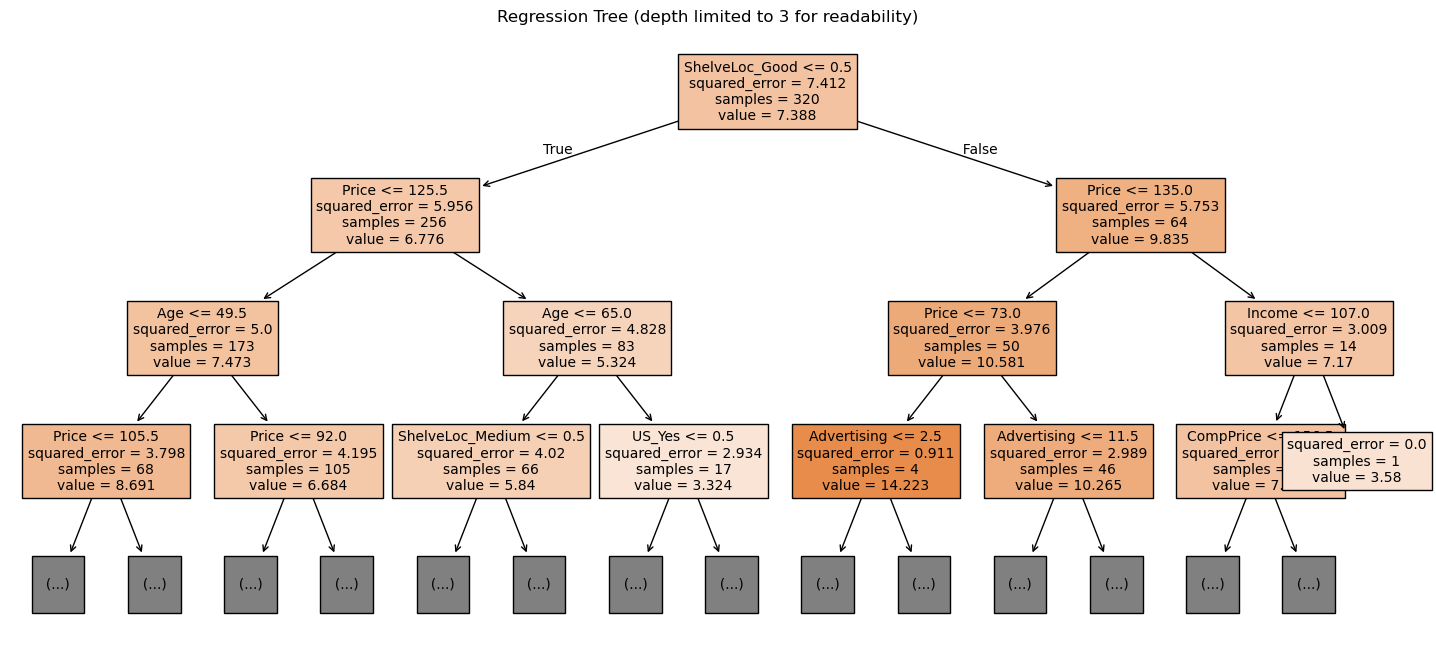

Top feature importances:
 Price               0.316731
ShelveLoc_Good      0.201956
Age                 0.123332
CompPrice           0.099265
ShelveLoc_Medium    0.060389
Advertising         0.056566
Income              0.047179
Education           0.043046
Population          0.032914
Urban_Yes           0.010678
dtype: float64
Test MSE: 6.1789


In [5]:
# (b) Fit a regression tree to the training set, plot it, and compute test MSE
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# Prepare predictors and response. Use get_dummies on the combined data to ensure consistent columns
combined = pd.concat([train, test])
X_comb = pd.get_dummies(combined.drop('Sales', axis=1), drop_first=True)
X_train = X_comb.loc[train.index]
X_test = X_comb.loc[test.index]
y_train = train['Sales']
y_test = test['Sales']

# Fit regression tree
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Plot the tree (limited depth for readability)
plt.figure(figsize=(18,8))
plot_tree(tree_reg, feature_names=X_train.columns, filled=True, max_depth=3, fontsize=10)
plt.title('Regression Tree (depth limited to 3 for readability)')
plt.show()

# Feature importances (top 10)
feat_imp = pd.Series(tree_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Top feature importances:\n', feat_imp.head(10))

# Test MSE
pred_test = tree_reg.predict(X_test)
mse_test = mean_squared_error(y_test, pred_test)
print(f'Test MSE: {mse_test:.4f}')

(c)
Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

Unpruned test MSE: 6.1789
Best ccp_alpha from CV: 1.582038e-02 with CV MSE 4.8656
Best ccp_alpha from CV: 1.582038e-02 with CV MSE 4.8656


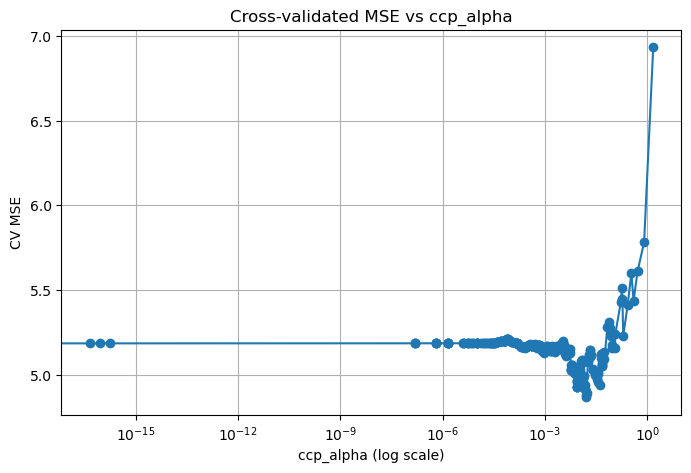

Pruned test MSE: 5.3588
Pruning improved the test MSE.


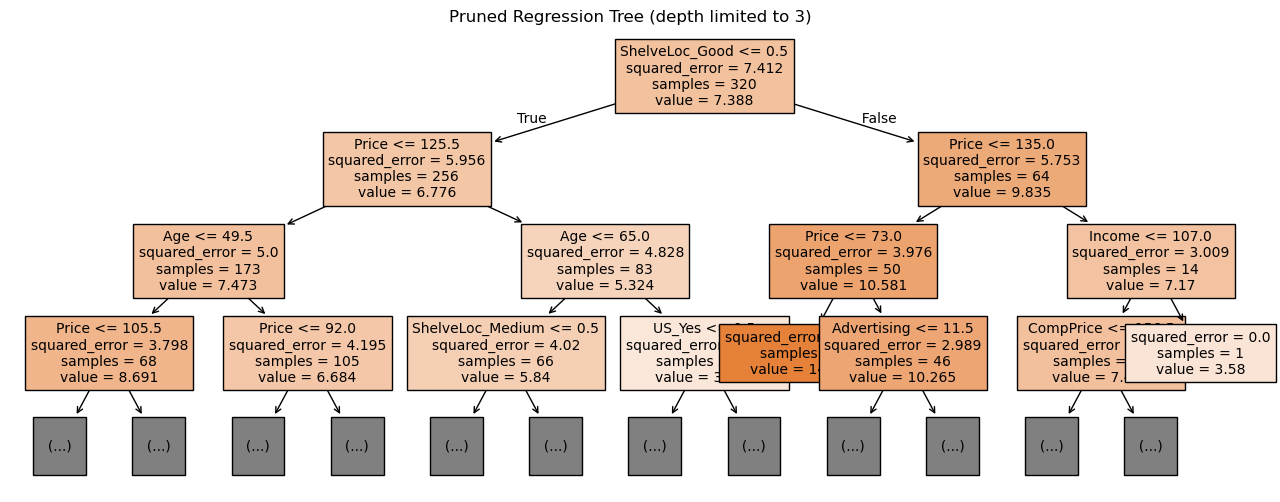

In [6]:
# (c) Use cross-validation to determine optimal tree complexity (ccp_alpha) and test pruning
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Refit an unpruned tree on the training set to get a baseline
unpruned = DecisionTreeRegressor(random_state=42)
unpruned.fit(X_train, y_train)
pred_unpruned = unpruned.predict(X_test)
mse_unpruned = mean_squared_error(y_test, pred_unpruned)
print(f'Unpruned test MSE: {mse_unpruned:.4f}')

# Get cost-complexity pruning path (effective alphas) from the training data
path = unpruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
# Remove the maximum alpha which prunes all nodes (optional) to avoid degenerate tree
ccp_alphas = ccp_alphas[ccp_alphas >= 0]

# For each candidate alpha, compute 5-fold CV MSE on training set
cv_mses = []
for a in ccp_alphas:
    reg = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    scores = cross_val_score(reg, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    cv_mses.append(np.mean(-scores))

cv_mses = np.array(cv_mses)
# Select alpha with lowest CV MSE
best_idx = np.argmin(cv_mses)
best_alpha = ccp_alphas[best_idx]
print(f'Best ccp_alpha from CV: {best_alpha:.6e} with CV MSE {cv_mses[best_idx]:.4f}')

# Plot CV MSE vs alpha (log scale)
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, cv_mses, marker='o')
plt.xscale('log')
plt.xlabel('ccp_alpha (log scale)')
plt.ylabel('CV MSE')
plt.title('Cross-validated MSE vs ccp_alpha')
plt.grid(True)
plt.show()

# Fit pruned tree with the best alpha and evaluate on test set
pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned.fit(X_train, y_train)
pred_pruned = pruned.predict(X_test)
mse_pruned = mean_squared_error(y_test, pred_pruned)
print(f'Pruned test MSE: {mse_pruned:.4f}')

if mse_pruned < mse_unpruned:
    print('Pruning improved the test MSE.')
else:
    print('Pruning did not improve the test MSE.')

# Optional: plot the pruned tree (shallow depth for readability)
plt.figure(figsize=(16,6))
plot_tree(pruned, feature_names=X_train.columns, filled=True, max_depth=3, fontsize=10)
plt.title('Pruned Regression Tree (depth limited to 3)')
plt.show()

(d)
Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

Bagging test MSE: 3.1087
Top feature importances (bagging):
 Price               0.309172
ShelveLoc_Good      0.198268
Age                 0.120176
CompPrice           0.092573
Advertising         0.082520
ShelveLoc_Medium    0.064372
Income              0.052222
Population          0.039527
Education           0.030512
Urban_Yes           0.006091
dtype: float64


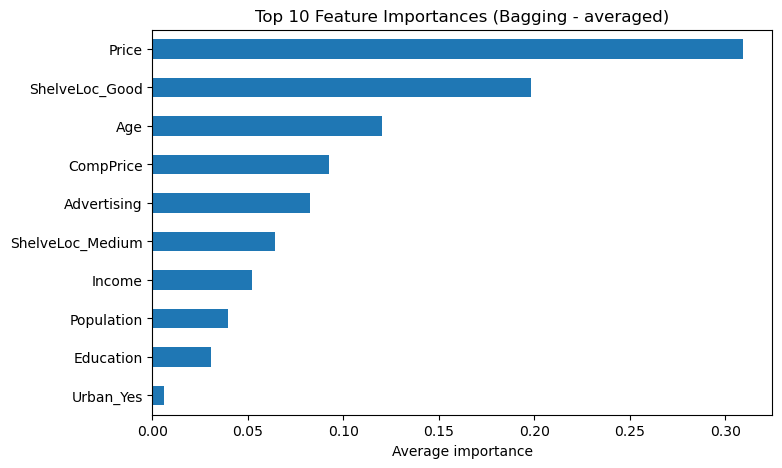

In [8]:
# (d) Use bagging to analyze the data: train BaggingRegressor, compute test MSE, and average feature importances
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

# Train a bagging ensemble of regression trees
bag = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42, n_jobs=-1)
bag.fit(X_train, y_train)

# Predictions and test MSE
pred_bag = bag.predict(X_test)
mse_bag = mean_squared_error(y_test, pred_bag)
print(f'Bagging test MSE: {mse_bag:.4f}')

# Feature importances: average feature_importances_ over all fitted trees
all_imps = np.array([est.feature_importances_ for est in bag.estimators_])
avg_imps = np.mean(all_imps, axis=0)
feat_imp_bag = pd.Series(avg_imps, index=X_train.columns).sort_values(ascending=False)
print('Top feature importances (bagging):\n', feat_imp_bag.head(10))

# Plot top 10 importances
plt.figure(figsize=(8,5))
feat_imp_bag.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances (Bagging - averaged)')
plt.xlabel('Average importance')
plt.show()

(e)
Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

Number of predictors (p): 11
m=  1  --> Test MSE: 5.4166
m=  3  --> Test MSE: 3.7483
m=  3  --> Test MSE: 3.7483
m=  3  --> Test MSE: 3.7483
m=  3  --> Test MSE: 3.7483
m= 11  --> Test MSE: 3.0130

Best max_features (m): 11 with Test MSE = 3.0130
Top feature importances (random forest - best m):
 Price               0.313937
ShelveLoc_Good      0.197075
Age                 0.118013
CompPrice           0.095935
Advertising         0.081879
ShelveLoc_Medium    0.059980
Income              0.050736
Population          0.040648
Education           0.030094
Urban_Yes           0.006633
dtype: float64
m= 11  --> Test MSE: 3.0130

Best max_features (m): 11 with Test MSE = 3.0130
Top feature importances (random forest - best m):
 Price               0.313937
ShelveLoc_Good      0.197075
Age                 0.118013
CompPrice           0.095935
Advertising         0.081879
ShelveLoc_Medium    0.059980
Income              0.050736
Population          0.040648
Education           0.030094
Urban_Y

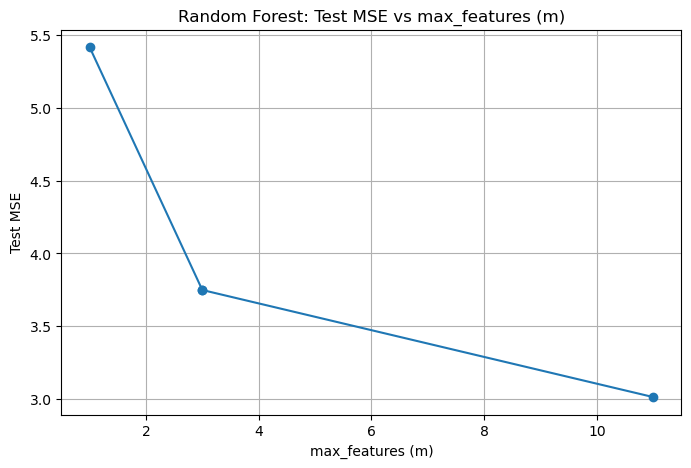

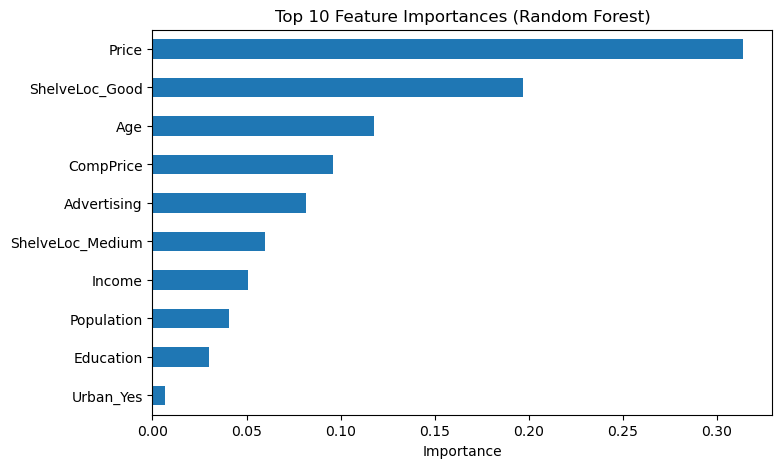

In [9]:
# (e) Use random forests to analyze this data. Compare effect of different m (max_features).
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Number of predictors
p = X_train.shape[1]
print(f'Number of predictors (p): {p}')

# Try several choices for m (max_features): 1, sqrt(p), p/3, p (use integers)
m_values = [1, max(1, int(np.sqrt(p))), max(1, int(p/3)), p]
results = []
for m in m_values:
    rf = RandomForestRegressor(n_estimators=200, max_features=m, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append((m, mse, rf))
    print(f'm={m:3d}  --> Test MSE: {mse:.4f}')

# Summarize results and pick best m (lowest MSE)
results_sorted = sorted(results, key=lambda x: x[1])
best_m, best_mse, best_rf = results_sorted[0]
print(f'\nBest max_features (m): {best_m} with Test MSE = {best_mse:.4f}')

# Feature importances from the best model
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Top feature importances (random forest - best m):\n', feat_imp_rf.head(10))

# Plot Test MSE vs m
ms = [r[0] for r in results]
ms_mse = [r[1] for r in results]
plt.figure(figsize=(8,5))
plt.plot(ms, ms_mse, marker='o')
plt.xlabel('max_features (m)')
plt.ylabel('Test MSE')
plt.title('Random Forest: Test MSE vs max_features (m)')
plt.grid(True)
plt.show()

# Optional: plot top 10 importances
plt.figure(figsize=(8,5))
feat_imp_rf.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

(f)
Now analyze the data using BART, and report your results.

BART test MSE: 1.2698
Top feature importances (permutation importance):
 ShelveLoc_Good      0.918679
Price               0.781001
CompPrice           0.286325
Advertising         0.170526
ShelveLoc_Medium    0.159604
Age                 0.080972
Income              0.038209
Urban_Yes           0.002839
Population          0.002368
US_Yes             -0.001070
dtype: float64
Top feature importances (permutation importance):
 ShelveLoc_Good      0.918679
Price               0.781001
CompPrice           0.286325
Advertising         0.170526
ShelveLoc_Medium    0.159604
Age                 0.080972
Income              0.038209
Urban_Yes           0.002839
Population          0.002368
US_Yes             -0.001070
dtype: float64


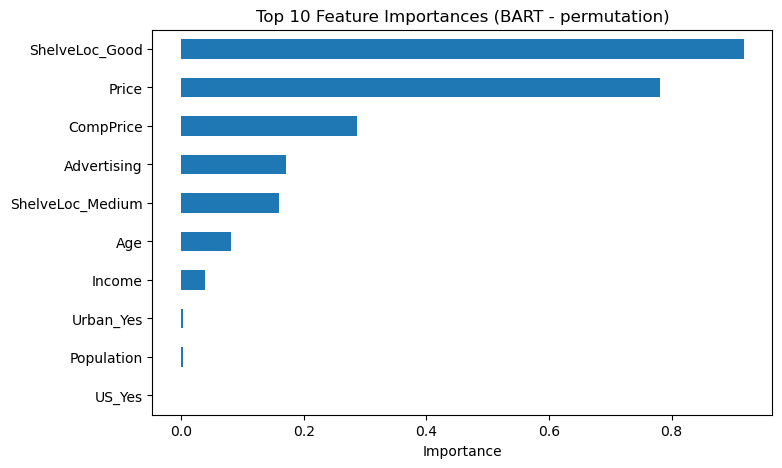

In [16]:
# (f) Analyze the data using BART from ISLP.bart
from ISLP.bart import BART
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Fit BART (ISLP.bart) on training data and evaluate on test data
# Ensure predictors and response are numeric numpy arrays (BART expects numeric inputs)
try:
    Xtrain_np = X_train.astype(float).values
    Xtest_np = X_test.astype(float).values
    ytrain_np = y_train.astype(float).values
    ytest_np = y_test.astype(float).values
except Exception as e:
    print('Error converting inputs to numeric. Column dtypes:')
    print(X_train.dtypes)
    raise

model = BART()
model.fit(Xtrain_np, ytrain_np)
pred = model.predict(Xtest_np)
mse = mean_squared_error(ytest_np, pred)
print(f'BART test MSE: {mse:.4f}')

# Permutation importance (model must implement predict)
perm = permutation_importance(model, Xtest_np, ytest_np, n_repeats=20, random_state=42, n_jobs=-1)
feat_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('Top feature importances (permutation importance):\n', feat_imp.head(10))

# Optional: display importance bar plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
feat_imp.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances (BART - permutation)')
plt.xlabel('Importance')
plt.show()